# Image Classification Project: Fruits 360

## 1. Install & Import Library

In [1]:
!pip install kaggle -q

In [2]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Download Dataset from Kaggle

In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d moltean/fruits
!unzip -q fruits.zip -d fruits_dataset
print('✅ Dataset downloaded successfully!')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 5.40G/5.40G [01:19<00:00, 220MB/s]
100% 5.40G/5.40G [01:19<00:00, 73.3MB/s]
✅ Dataset downloaded successfully!


## 3. Exploration & Select 5 Classes

In [4]:
base_dir  = 'fruits_dataset/fruits-360_100x100/fruits-360'
train_dir = os.path.join(base_dir, 'Training')
test_dir  = os.path.join(base_dir, 'Test')

classes = sorted(os.listdir(train_dir))
print(f'Total classes available: {len(classes)}')

Total classes available: 253


In [5]:
keywords = [
    'apple', 'banana', 'cherry', 'grape', 'kiwi',
    'lemon', 'mango', 'orange', 'pineapple', 'strawberry',
    'pear', 'peach', 'plum', 'tomato', 'avocado',
    'blueberry', 'raspberry', 'watermelon', 'coconut', 'fig'
]

print('=== Available class names ===')\nfor kw in keywords:\n    matches = [c for c in classes if kw.lower() in c.lower()]\n    print(f'{kw:12s}: {matches[:5]}')

=== Available class names ===
apple       : ['Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14']
banana      : ['Banana 1', 'Banana 3', 'Banana 4', 'Banana Lady Finger 1', 'Banana Red 1']
cherry      : ['Cherry 1', 'Cherry 2', 'Cherry 3', 'Cherry 4', 'Cherry 5']
grape       : ['Grape 1', 'Grape Blue 1', 'Grape Pink 1', 'Grape White 1', 'Grape White 2']
kiwi        : ['Kiwi 1']
lemon       : ['Lemon 1', 'Lemon Meyer 1']
mango       : ['Mango 1', 'Mango Red 1', 'Mangostan 1']
orange      : ['Orange 1', 'Orange 2', 'Orange 3', 'Pepper Orange 1', 'Pepper Orange 2']
pineapple   : ['Pineapple 1', 'Pineapple Mini 1']
strawberry  : ['Strawberry 1', 'Strawberry 2', 'Strawberry 3', 'Strawberry Wedge 1']
pear        : ['Pear 1', 'Pear 10', 'Pear 11', 'Pear 12', 'Pear 13']
peach       : ['Peach 1', 'Peach 2', 'Peach 3', 'Peach 4', 'Peach 5']
plum        : ['Plum 1', 'Plum 2', 'Plum 3', 'Plum 4', 'Plum 5']
tomato      : ['Tomato 1', 'Tomato 10', 'Tomato 11', 'Tomato 2', 'Tomato 3']
avocado 

In [6]:
keywords = [
    'apple', 'banana', 'cherry', 'grape', 'kiwi',
    'lemon', 'mango', 'orange', 'pineapple', 'strawberry',
    'pear', 'peach', 'plum', 'tomato', 'avocado',
    'blueberry', 'raspberry', 'watermelon', 'coconut', 'fig'
]

SELECTED_CLASSES = []
for kw in keywords:
    matches = [c for c in classes if kw.lower() in c.lower()]
    if matches:
        SELECTED_CLASSES.append(matches[0])

print(f'Classes used ({len(SELECTED_CLASSES)}):')\nfor cls in SELECTED_CLASSES:\n    n = len(os.listdir(os.path.join(train_dir, cls)))\n    print(f'  - {cls}: {n} images')

Classes used (19):
  - Apple 10: 699 images
  - Banana 1: 490 images
  - Cherry 1: 492 images
  - Grape 1: 469 images
  - Kiwi 1: 466 images
  - Lemon 1: 492 images
  - Mango 1: 490 images
  - Orange 1: 479 images
  - Pineapple 1: 490 images
  - Strawberry 1: 492 images
  - Pear 1: 492 images
  - Peach 1: 492 images
  - Plum 1: 447 images
  - Tomato 1: 738 images
  - Avocado 1: 427 images
  - Blueberry 1: 462 images
  - Raspberry 1: 490 images
  - Watermelon 1: 475 images
  - Fig 1: 702 images


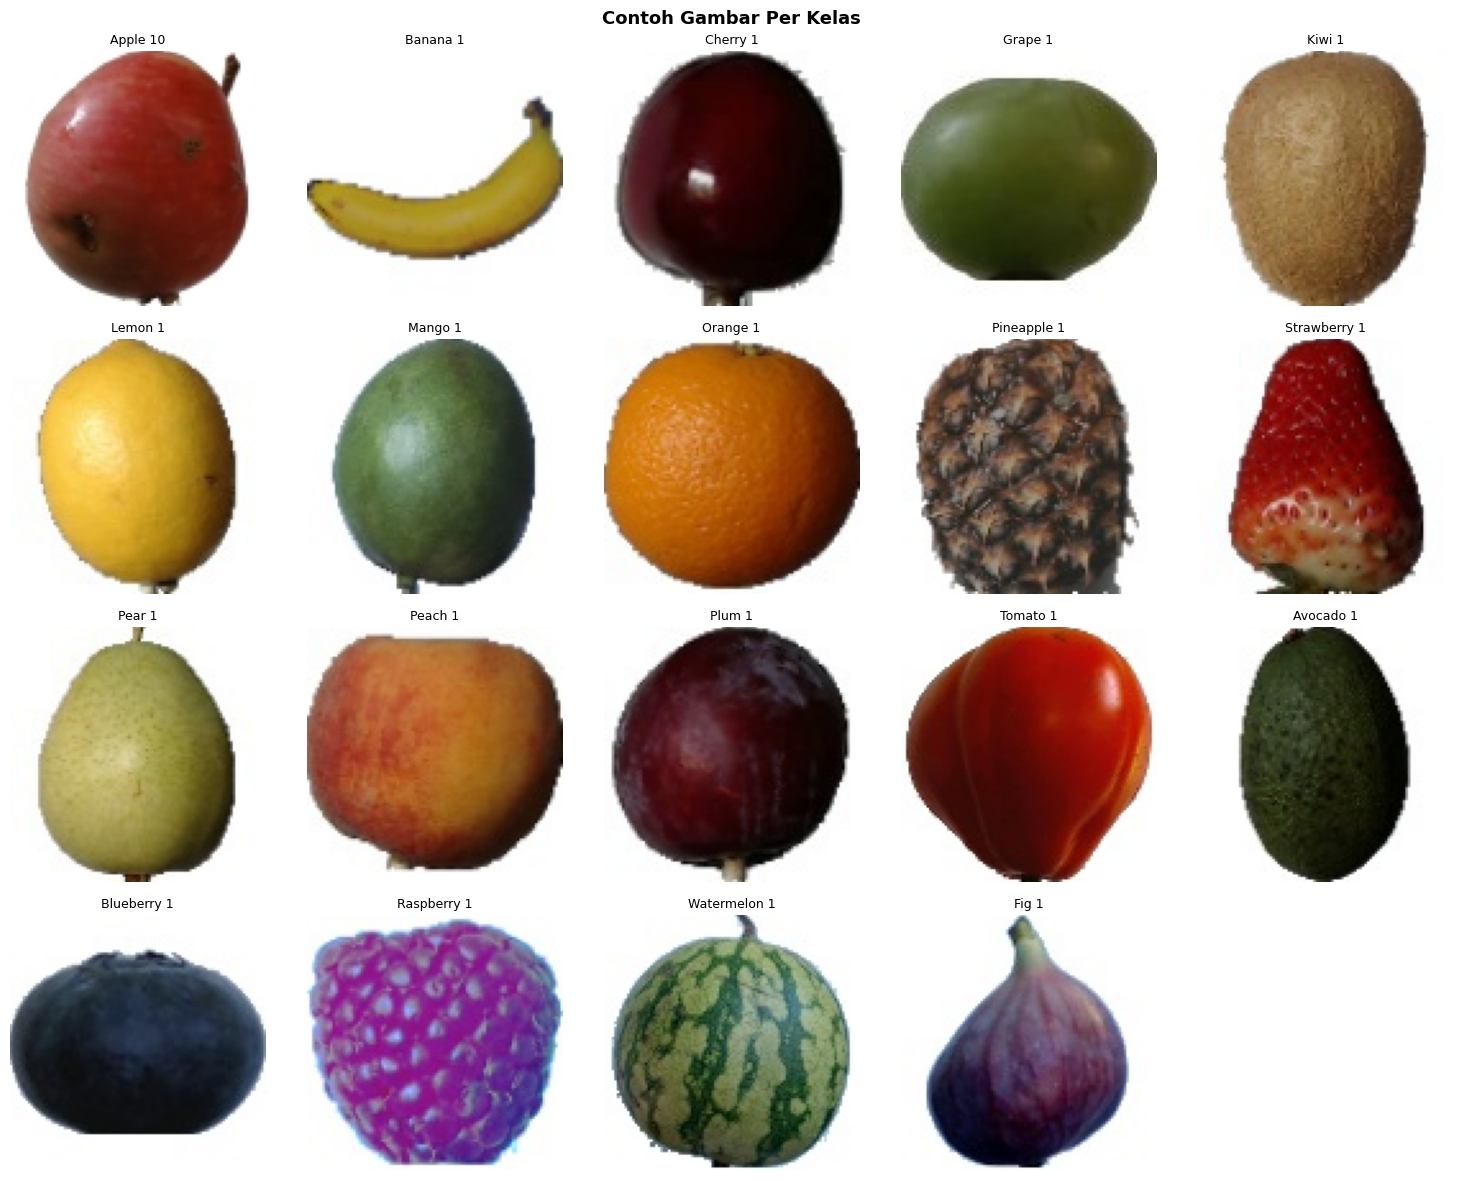

In [9]:
import math

num_classes = len(SELECTED_CLASSES)
num_cols    = 5
num_rows    = math.ceil(num_classes / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes      = axes.flatten()

for i, cls in enumerate(SELECTED_CLASSES):
    cls_dir  = os.path.join(train_dir, cls)
    img_file = os.listdir(cls_dir)[0]
    img      = plt.imread(os.path.join(cls_dir, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sample Images Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Split Dataset (Train 70% / Validation 20% / Test 10%)

In [10]:
SPLIT_DIR   = 'fruits_split'
TRAIN_SPLIT = 0.7
VAL_SPLIT   = 0.2
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = len(SELECTED_CLASSES)

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
    print('Old folder deleted!')

for split in ['train', 'validation', 'test']:
    for cls in SELECTED_CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in SELECTED_CLASSES:
    cls_dir = os.path.join(train_dir, cls)
    images  = os.listdir(cls_dir)
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * TRAIN_SPLIT)
    n_val   = int(n * VAL_SPLIT)

    split_map = {
        'train'     : images[:n_train],
        'validation': images[n_train:n_train + n_val],
        'test'      : images[n_train + n_val:]
    }

    for split_name, split_imgs in split_map.items():
        for img in split_imgs:
            shutil.copy2(
                os.path.join(cls_dir, img),
                os.path.join(SPLIT_DIR, split_name, cls, img)
            )

print('\n=== Number of Images Per Split ===')
for split in ['train', 'validation', 'test']:
    total = sum([
        len(os.listdir(os.path.join(SPLIT_DIR, split, c)))
        for c in SELECTED_CLASSES
    ])
    print(f'{split:12s}: {total} images')


=== Number of Images Per Split ===
train       : 6842 images
validation  : 1950 images
test        : 992 images


## 5. Data Augmentation & Generator

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nNumber of classes : {NUM_CLASSES}')
print(f'Class indices: {train_generator.class_indices}')

Found 6842 images belonging to 19 classes.
Found 1950 images belonging to 19 classes.
Found 992 images belonging to 19 classes.

Number of classes : 19
Class indices: {'Apple 10': 0, 'Avocado 1': 1, 'Banana 1': 2, 'Blueberry 1': 3, 'Cherry 1': 4, 'Fig 1': 5, 'Grape 1': 6, 'Kiwi 1': 7, 'Lemon 1': 8, 'Mango 1': 9, 'Orange 1': 10, 'Peach 1': 11, 'Pear 1': 12, 'Pineapple 1': 13, 'Plum 1': 14, 'Raspberry 1': 15, 'Strawberry 1': 16, 'Tomato 1': 17, 'Watermelon 1': 18}


## 6. Build Model (Transfer Learning MobileNetV2 + Conv2D + Pooling)

In [12]:
# Load MobileNetV2 pretrained, tanpa top layer
base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all base model layers\nbase_model.trainable = False\n\n# Build Sequential model\nmodel = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    # Base model (pretrained)
    base_model,

    # ✅ Additional Conv2D + Pooling (per criteria)\n    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Fully Connected
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='MobileNetV2_Fruits360')

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Fruits360"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,829,011 (14.61 MB)

 Trainable params: 1,570,515 (5.99 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

## 7. Compile Model

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('✅ Model compiled successfully!')

✅ Model compiled successfully!


## 8. Callbacks

In [14]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]
print('✅ Callbacks ready!')

✅ Callbacks siap!


## 9. Training Model (Phase 1 - Frozen Base)

In [15]:
print('=== Phase 1: Training with frozen base model ===')
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

=== Phase 1: Training dengan frozen base model ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.7234 - loss: 1.0036
Epoch 1: val_accuracy improved from -inf to 0.98923, saving model to best_model.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 134s 522ms/step - accuracy: 0.7242 - loss: 1.0009 - val_accuracy: 0.9892 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9964 - loss: 0.0326
Epoch 2: val_accuracy did not improve from 0.98923
214/214 ━━━━━━━━━━━━━━━━━━━━ 80s 375ms/step - accuracy: 0.9964 - loss: 0.0325 - val_accuracy: 0.9887 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 3/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9939 - loss: 0.0281
Epoch 3: val_accuracy improved from 0.98923 to 0.99744, saving model to best_model.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 81s 378ms/step - accuracy: 0.9939 - loss: 0.0280 - val_accuracy: 0.9974 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 4/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9971 - lo

## 10. Fine-Tuning (Phase 2 - Unfreeze Some Layers)

In [16]:
# Unfreeze last 30 layers from base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with smaller learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Phase 2: Fine-tuning ===')
history_ft = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

=== Phase 2: Fine-tuning ===
Epoch 1/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9160 - loss: 0.2904
Epoch 1: val_accuracy did not improve from 1.00000
214/214 ━━━━━━━━━━━━━━━━━━━━ 119s 466ms/step - accuracy: 0.9161 - loss: 0.2899 - val_accuracy: 1.0000 - val_loss: 6.0730e-04 - learning_rate: 1.0000e-05
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9834 - loss: 0.0659
Epoch 2: val_accuracy did not improve from 1.00000
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 385ms/step - accuracy: 0.9834 - loss: 0.0658 - val_accuracy: 1.0000 - val_loss: 6.7479e-04 - learning_rate: 1.0000e-05
Epoch 3/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9884 - loss: 0.0443
Epoch 3: val_accuracy did not improve from 1.00000
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 381ms/step - accuracy: 0.9884 - loss: 0.0443 - val_accuracy: 1.0000 - val_loss: 6.3015e-04 - learning_rate: 1.0000e-05
Epoch 4/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.9935 - loss: 0.0274
Epoch 4: 

## 11. Plot Accuracy & Loss

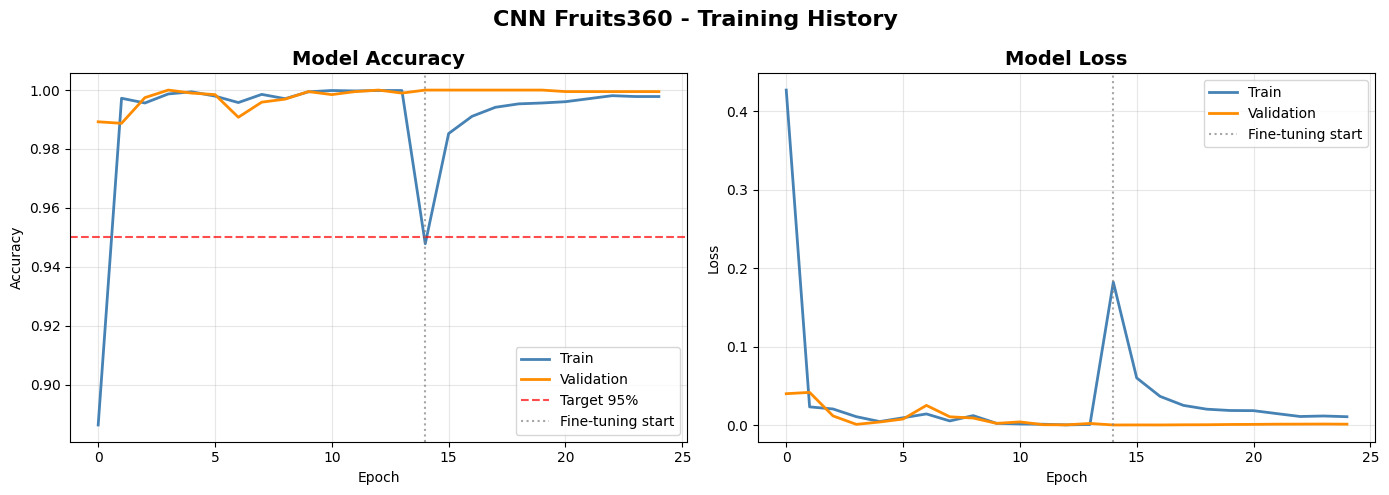

✅ Plot saved as training_history.png


In [17]:
# Combine history phase 1 and phase 2\ndef combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

hist = combine_history(history, history_ft)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(hist['accuracy'],     label='Train',      color='steelblue',  linewidth=2)
ax1.plot(hist['val_accuracy'], label='Validation', color='darkorange', linewidth=2)
ax1.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='Target 95%')
ax1.axvline(x=len(history.history['accuracy']), color='gray',
            linestyle=':', alpha=0.7, label='Fine-tuning start')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Loss
ax2.plot(hist['loss'],     label='Train',      color='steelblue',  linewidth=2)
ax2.plot(hist['val_loss'], label='Validation', color='darkorange', linewidth=2)
ax2.axvline(x=len(history.history['loss']), color='gray',
            linestyle=':', alpha=0.7, label='Fine-tuning start')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Fruits360 - Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as training_history.png')

## 12. Model Evaluation

In [18]:
print('=== Evaluation on Test Set ===')
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

print('\n=== Evaluation on Train Set ===')
train_loss, train_acc = model.evaluate(train_generator, verbose=1)
print(f'\nTrain Loss    : {train_loss:.4f}')
print(f'Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)')

=== Evaluasi pada Test Set ===
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 1.0000 - loss: 3.6816e-04

Test Loss    : 0.0002
Test Accuracy: 1.0000 (100.00%)

=== Evaluasi pada Train Set ===
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 370ms/step - accuracy: 1.0000 - loss: 4.6390e-04

Train Loss    : 0.0005
Train Accuracy: 1.0000 (100.00%)


## 13. Save Model - SavedModel

In [19]:
saved_model_path = 'saved_model/fruits_cnn'
model.export(saved_model_path)
print(f'✅ SavedModel saved at: {saved_model_path}')

Saved artifact at 'saved_model/fruits_cnn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 19), dtype=tf.float32, name=None)
Captures:
  136032761002512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032760995600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761000208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761000016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761000976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761000400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761001552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761003664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761001360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136032761002320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136

## 14. Save Model - TF-Lite

In [20]:
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = 'fruits_cnn.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f'✅ TF-Lite saved at: {tflite_path}')
print(f'   Size: {os.path.getsize(tflite_path) / 1024:.1f} KB')

✅ TF-Lite saved at: fruits_cnn.tflite
   Size: 3991.7 KB


## 15. Save Model - TensorFlow.js (TFJS)

In [21]:
!pip install tensorflowjs -q
import tensorflowjs as tfjs

tfjs_path = 'tfjs_model'
tfjs.converters.save_keras_model(model, tfjs_path)
print(f'✅ TFJS saved at: {tfjs_path}/')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


failed to lookup keras version from the file,
    this is likely a weight only file
✅ TFJS saved at: tfjs_model/


## 16. Inference with TF-Lite (Inference Proof)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/tmp/ipykernel_574/419905823.py:41: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_574/419905823.py:42: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


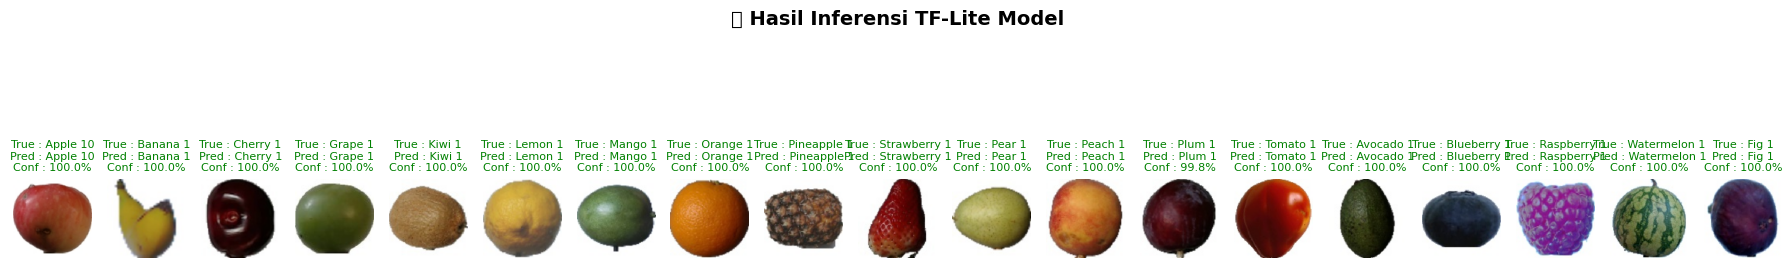


✅ Inference complete!


In [22]:
from tensorflow.keras.preprocessing import image as keras_image


interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
class_labels   = list(train_generator.class_indices.keys())

def predict_tflite(img_path):
    img       = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    preds      = interpreter.get_tensor(output_details[0]['index'])[0]
    pred_idx   = np.argmax(preds)
    return class_labels[pred_idx], preds[pred_idx] * 100, img

test_images = []
for cls in SELECTED_CLASSES:
    cls_dir = os.path.join(SPLIT_DIR, 'test', cls)
    imgs    = os.listdir(cls_dir)
    if imgs:
        test_images.append((os.path.join(cls_dir, imgs[0]), cls))

fig, axes = plt.subplots(1, len(test_images), figsize=(18, 4))
for i, (img_path, true_label) in enumerate(test_images):
    pred_label, confidence, img = predict_tflite(img_path)
    color = 'green' if pred_label == true_label else 'red'
    axes[i].imshow(img)
    axes[i].set_title(
        f'True : {true_label}\nPred : {pred_label}\nConf : {confidence:.1f}%',
        fontsize=8, color=color
    )
    axes[i].axis('off')

plt.suptitle('🔍 TF-Lite Model Inference Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Inference complete!')

In [23]:
import os
import shutil

os.makedirs('output/tfjs_model', exist_ok=True)
os.makedirs('output/tflite', exist_ok=True)
os.makedirs('output/saved_model', exist_ok=True)

shutil.copytree('tfjs_model', 'output/tfjs_model', dirs_exist_ok=True)

shutil.copy('fruits_cnn.tflite', 'output/tflite/model.tflite')


with open('output/tflite/label.txt', 'w') as f:
    for label in class_labels:
        f.write(label + '\n')

shutil.copytree('saved_model/fruits_cnn', 'output/saved_model', dirs_exist_ok=True)



readme = f"""# 🍎 CNN Image Classification - Fruits 360

## Description
Fruit image classification project using Transfer Learning (MobileNetV2) + Conv2D + Pooling.

## Classes
{chr(10).join([f'- {cls}' for cls in class_labels])}

## Accuracy
- Train Accuracy : {train_acc*100:.2f}%
- Test Accuracy  : {test_acc*100:.2f}%

## Model
- SavedModel : `saved_model/`
- TF-Lite    : `tflite/model.tflite`
- TFJS       : `tfjs_model/`
"""
with open('output/README.md', 'w') as f:
    f.write(readme)


reqs = """tensorflow>=2.10.0
tensorflowjs
numpy
matplotlib
scikit-learn
Pillow
"""
with open('output/requirements.txt', 'w') as f:
    f.write(reqs)


print('=== Submission Structure ===')\nfor root, dirs, files in os.walk('output'):
    level = root.replace('output', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        print(f'{indent}  {file}')

=== Struktur Submission ===
output/
  README.md
  requirements.txt
  saved_model/
    saved_model.pb
    fingerprint.pb
    variables/
      variables.data-00000-of-00001
      variables.index
    assets/
  tfjs_model/
    group1-shard2of4.bin
    group1-shard1of4.bin
    model.json
    group1-shard4of4.bin
    group1-shard3of4.bin
  tflite/
    label.txt
    model.tflite


In [24]:

shutil.make_archive('output', 'zip', '.', 'output')

from google.colab import files
files.download('output.zip')
print('✅ output.zip downloaded successfully!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ output.zip downloaded successfully!
